# نمایش اولیه دیتاست

In [17]:
import pandas as pd
file_path = r'C:\Users\ASUS\Desktop\Dataset 0172.xlsx'
df = pd.read_excel(file_path)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

df.head(20).style.background_gradient(cmap='Blues')

,No.,Tool Shape,Rotational Speed,Plunging Speed,Composite Volume Fraction (%),Si Particle Size (um),Hardness (HV),wear rate,Ultimate Compression Strength (MPa),Elongation (%)
0,1,1,315,25.000000,0,2.900000,75.000000,8.620000,118.000000,13.500000
1,2,1,315,31.500000,0,3.400000,72.000000,9.310000,135.000000,13.000000
2,3,1,315,40.000000,0,4.100000,69.000000,10.420000,119.000000,7.500000
3,4,1,500,25.000000,0,2.200000,81.000000,8.150000,115.000000,12.000000
4,5,1,500,31.500000,0,2.700000,75.000000,8.540000,136.000000,13.000000
5,6,1,500,40.000000,0,3.200000,72.000000,9.288000,140.000000,17.000000
6,7,1,630,25.000000,0,1.400000,83.000000,7.024000,101.000000,9.700000
7,8,1,630,31.500000,0,1.600000,81.000000,7.660000,125.800000,9.500000
8,9,1,630,40.000000,0,2.000000,78.000000,8.107000,138.700000,14.000000
9,10,1,800,25.000000,0,1.100000,84.000000,6.900000,98.000000,8.300000


# بررسی آمار توصیفی و تست نرمال بودن برای فیچرها

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

#  آماده سازی اولیه دیتاست و حذف ستون اضافی

if 'No.' in df.columns:
    df = df.drop(columns=['No.'])
    
# نمایش آمار توصیفی دیتاست
numeric_df = df.select_dtypes(include=[np.number])
stats_summary = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Mode': numeric_df.mode().iloc[0],
    'Std Dev': numeric_df.std(),
    'Variance': numeric_df.var(),
    'Skewness': numeric_df.skew(),
    'Kurtosis': numeric_df.kurtosis()
})

# اضافه کردن فاصله اطمینان ۹۵٪ به جدول
ci_bounds = numeric_df.apply(lambda x: stats.t.interval(0.95, len(x)-1, loc=np.mean(x), scale=stats.sem(x)))
stats_summary['CI_Lower'] = ci_bounds.iloc[0]
stats_summary['CI_Upper'] = ci_bounds.iloc[1]

print("--- Descriptive Statistics Table ---")
display(stats_summary.style.background_gradient(cmap='Blues').format("{:.3f}"))

#  تست نرمال بودن
norm_results = []
for col in numeric_df.columns:
    shapiro_p = stats.shapiro(numeric_df[col])[1]
    ks_p = stats.kstest(numeric_df[col], 'norm', args=(numeric_df[col].mean(), numeric_df[col].std()))[1]
    norm_results.append({'Feature': col, 'Shapiro_p': shapiro_p, 'KS_p': ks_p, 'Normal': shapiro_p > 0.05})

print("\n--- Normality Test Table ---")
display(pd.DataFrame(norm_results).set_index('Feature'))

--- Descriptive Statistics Table ---


,Mean,Median,Mode,Std Dev,Variance,Skewness,Kurtosis,CI_Lower,CI_Upper
Tool Shape,2.000,2.000,1.000,0.822,0.676,0.000,-1.521,1.807,2.193
Rotational Speed,561.250,565.000,315.000,178.812,31973.768,-0.056,-1.252,519.231,603.269
Plunging Speed,32.167,31.500,25.000,6.185,38.254,0.165,-1.521,30.713,33.620
Composite Volume Fraction (%),0.500,0.500,0.000,0.504,0.254,0.000,-2.058,0.382,0.618
Si Particle Size (um),1.191,0.840,0.400,0.940,0.883,1.061,0.313,0.971,1.412
Hardness (HV),83.527,83.750,81.000,6.175,38.132,-0.069,-0.528,82.076,84.978
wear rate,6.711,6.559,7.000,1.454,2.114,0.399,-0.611,6.369,7.053
Ultimate Compression Strength (MPa),139.678,140.000,128.000,19.209,368.971,0.036,-0.344,135.164,144.192
Elongation (%),13.432,13.100,11.000,3.263,10.644,0.596,0.232,12.665,14.198



--- Normality Test Table ---


,Shapiro_p,KS_p,Normal
Feature,,,
Tool Shape,1.120639e-08,1.401253e-03,False
Rotational Speed,1.054947e-06,3.380466e-02,False
Plunging Speed,8.458760e-09,7.511960e-04,False
Composite Volume Fraction (%),4.575570e-12,6.472595e-08,False
Si Particle Size (um),3.162229e-06,3.683280e-02,False
Hardness (HV),7.748489e-01,9.930271e-01,True
wear rate,5.205504e-02,6.761680e-01,True
Ultimate Compression Strength (MPa),9.661656e-01,9.999978e-01,True
Elongation (%),9.619153e-02,4.680571e-01,True


# بررسی همبستگی و رسم نمودارهای توزیع فیچرها

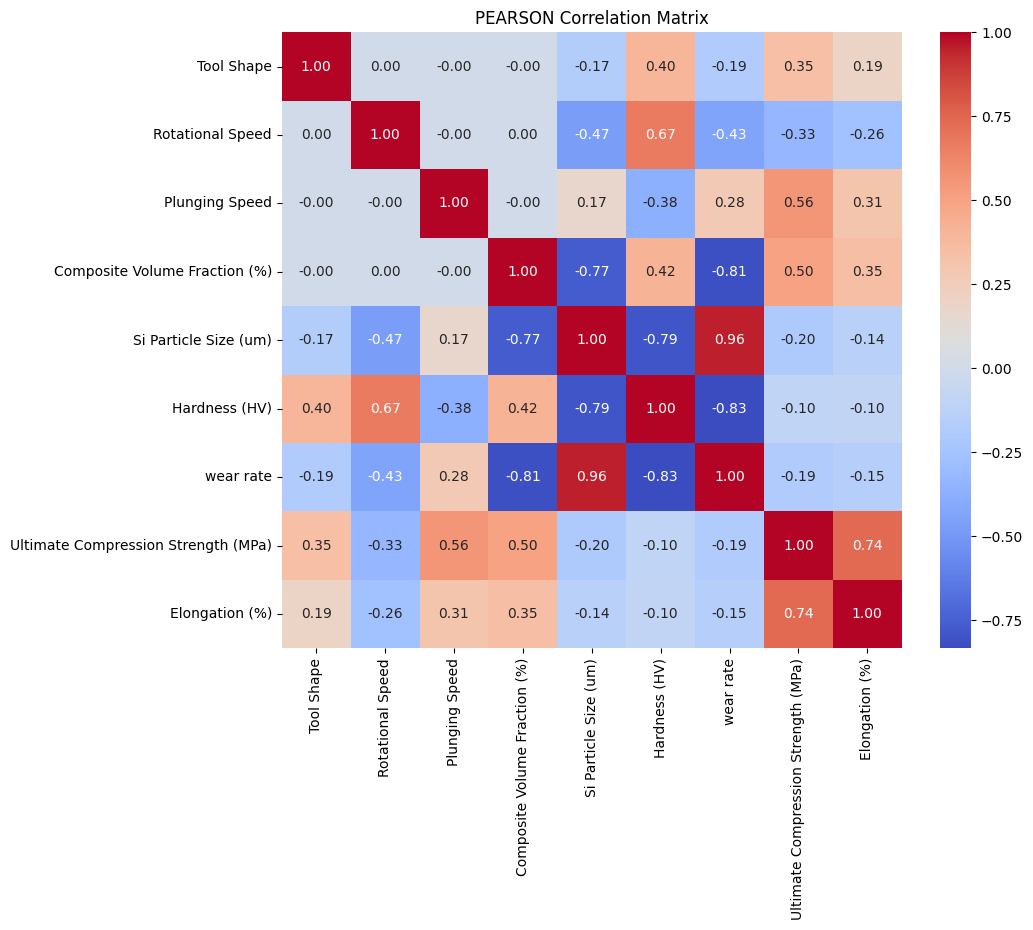

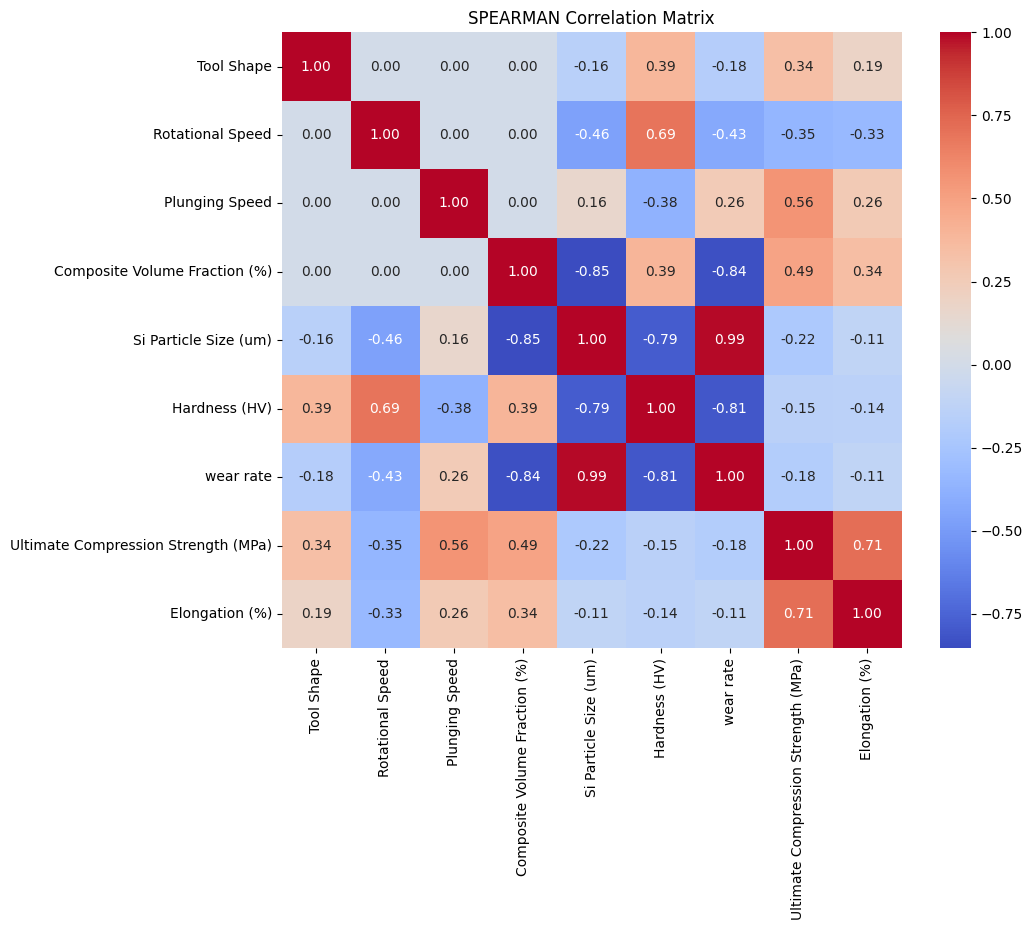

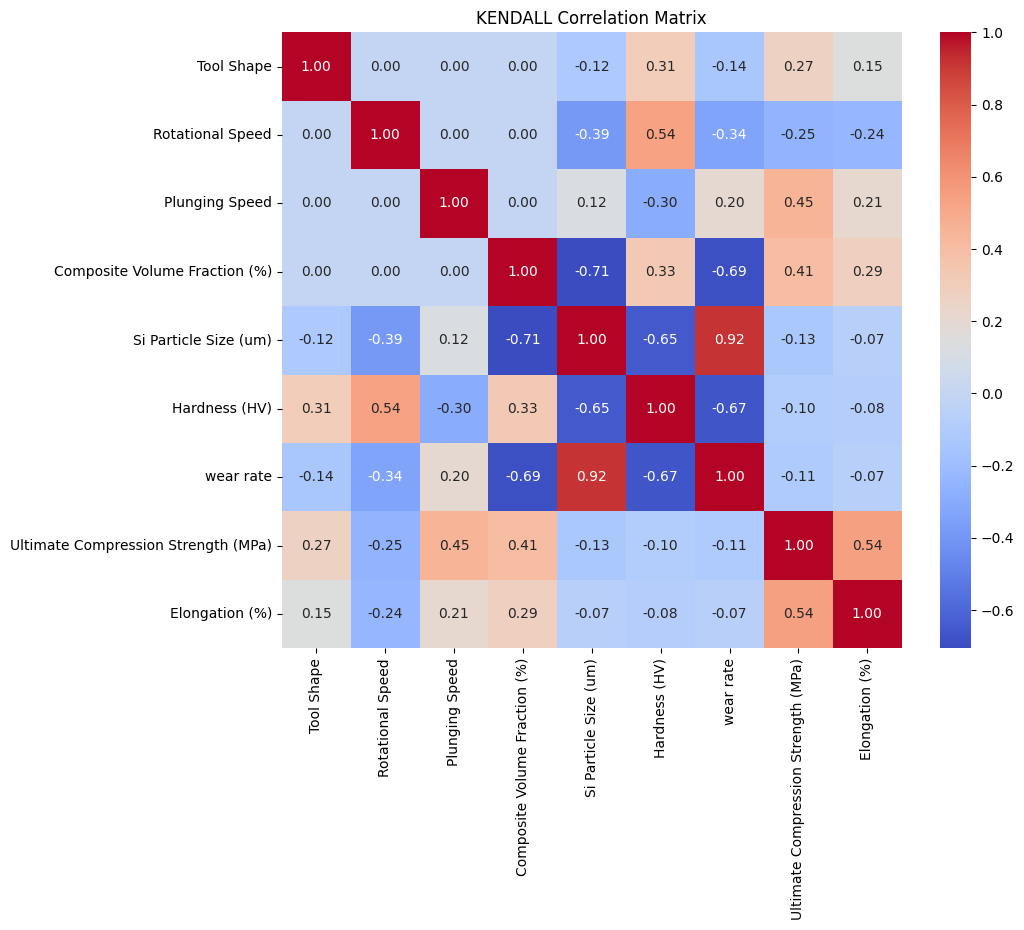

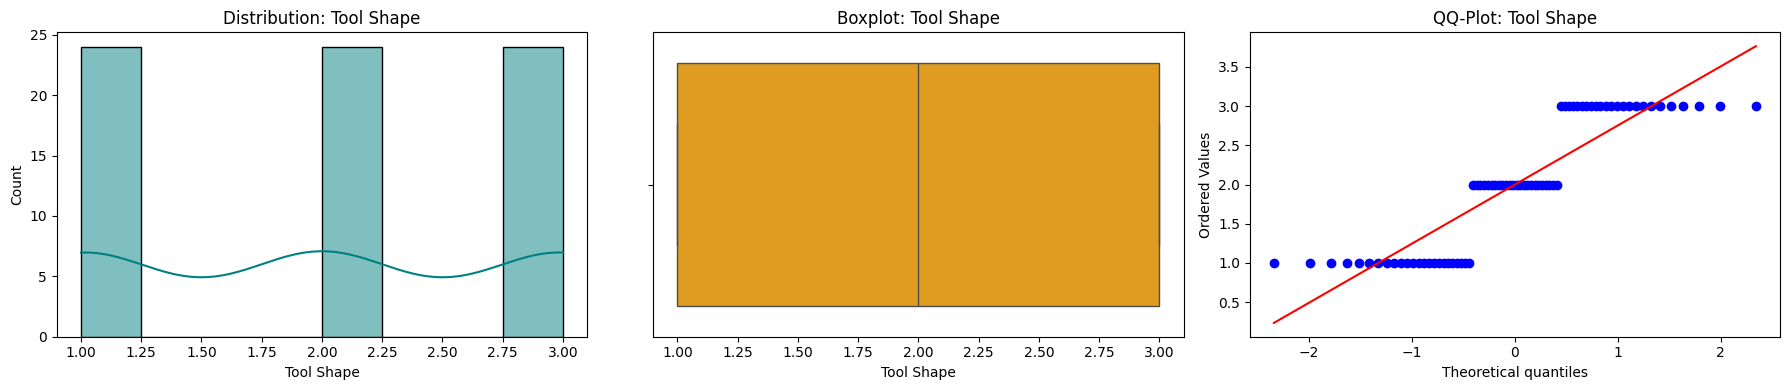

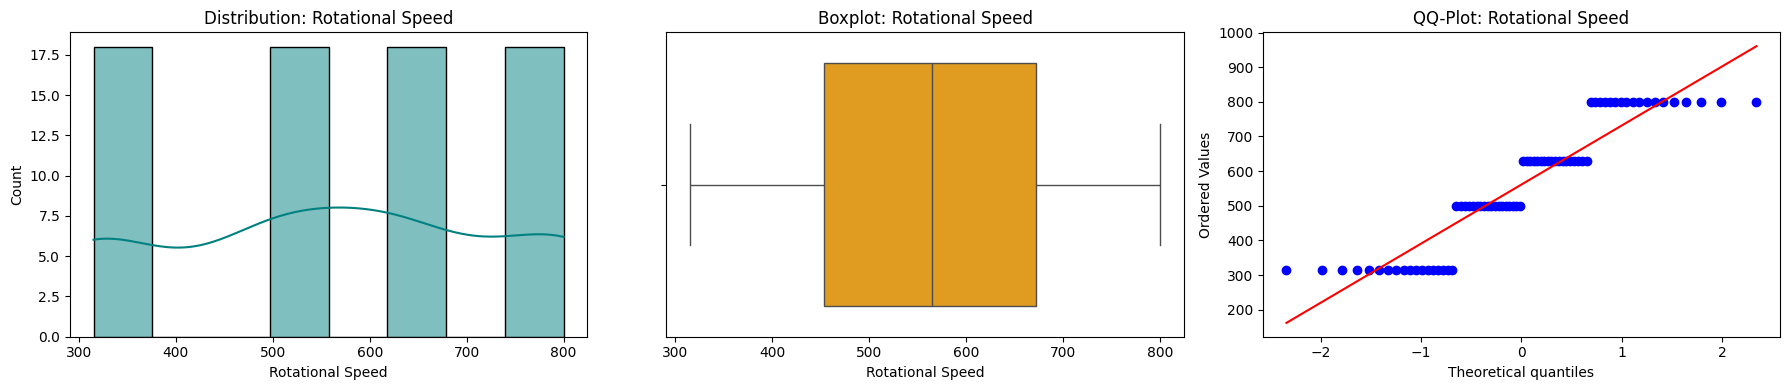

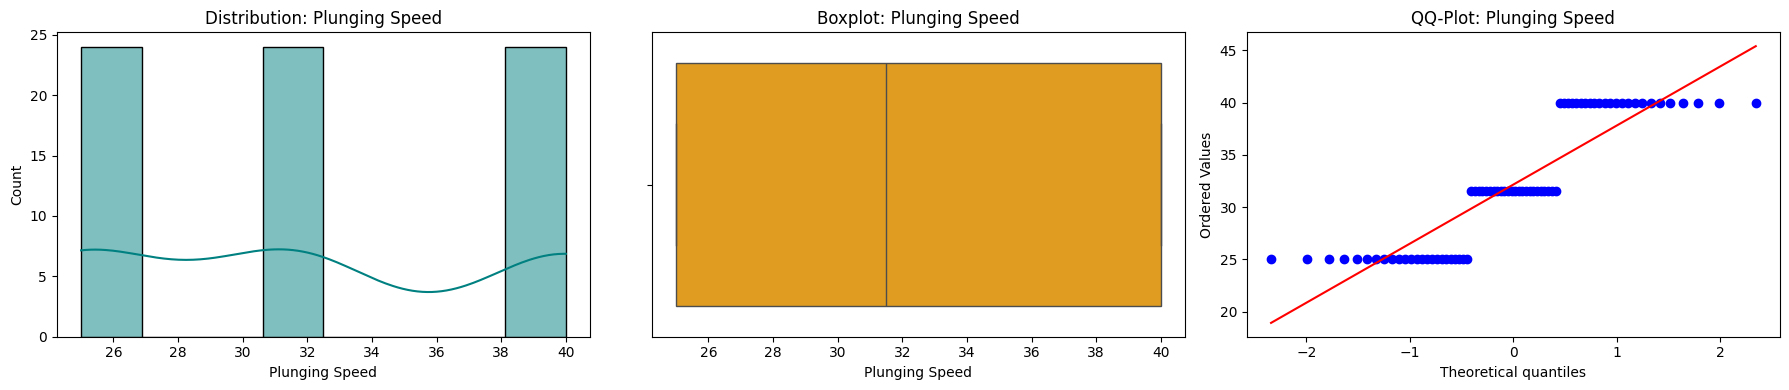

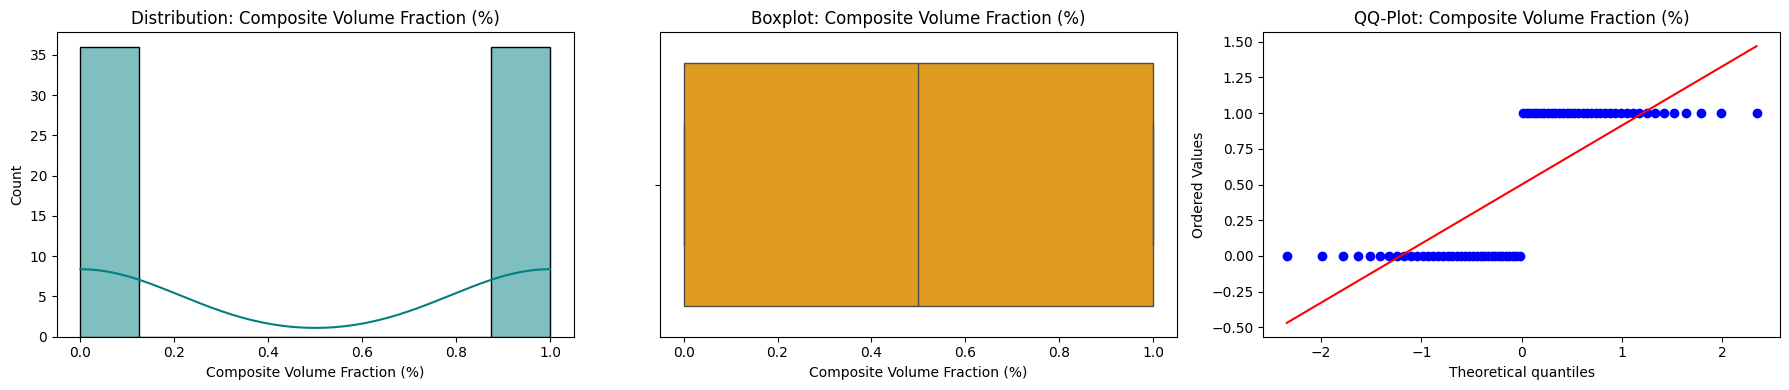

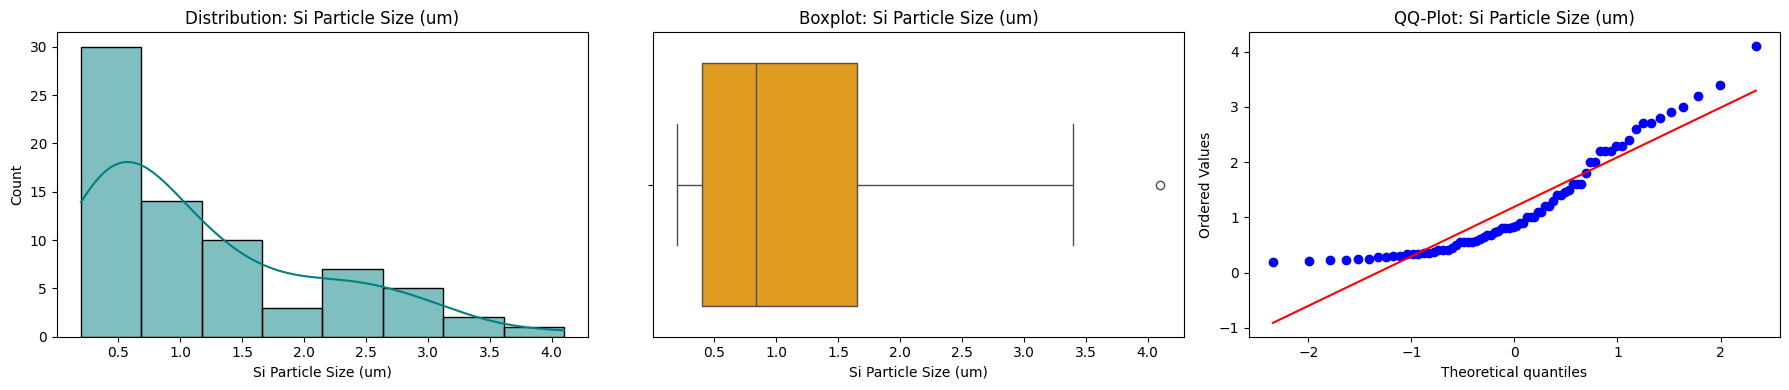

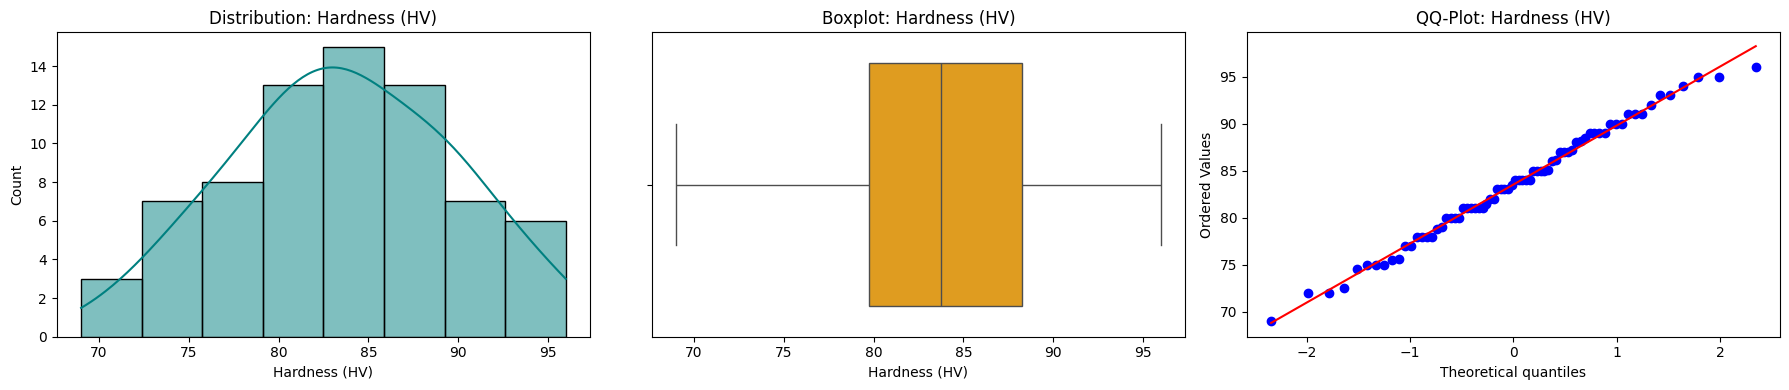

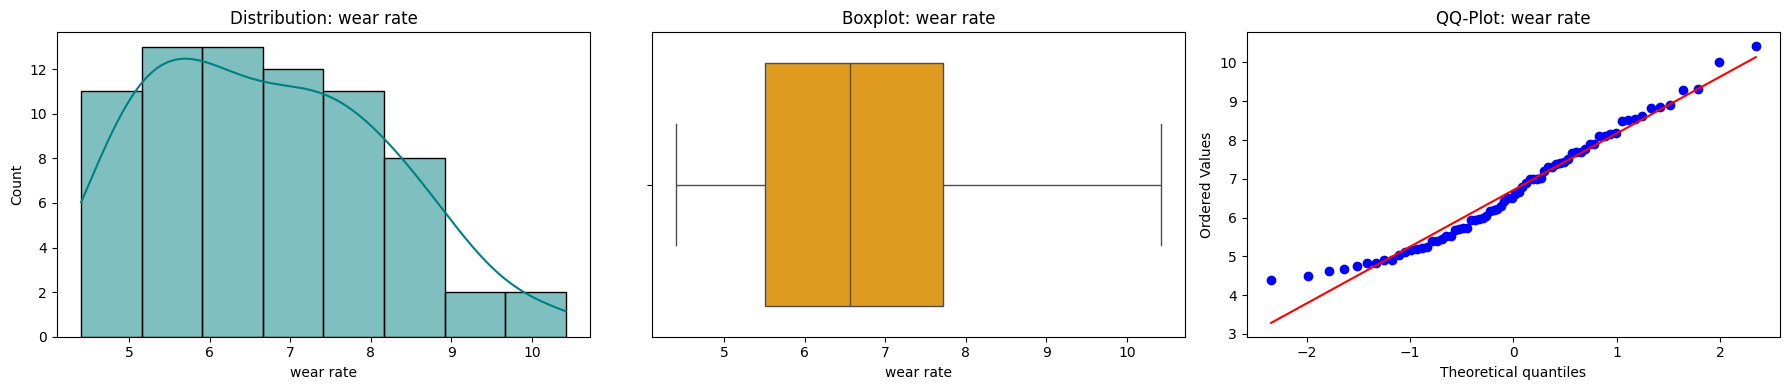

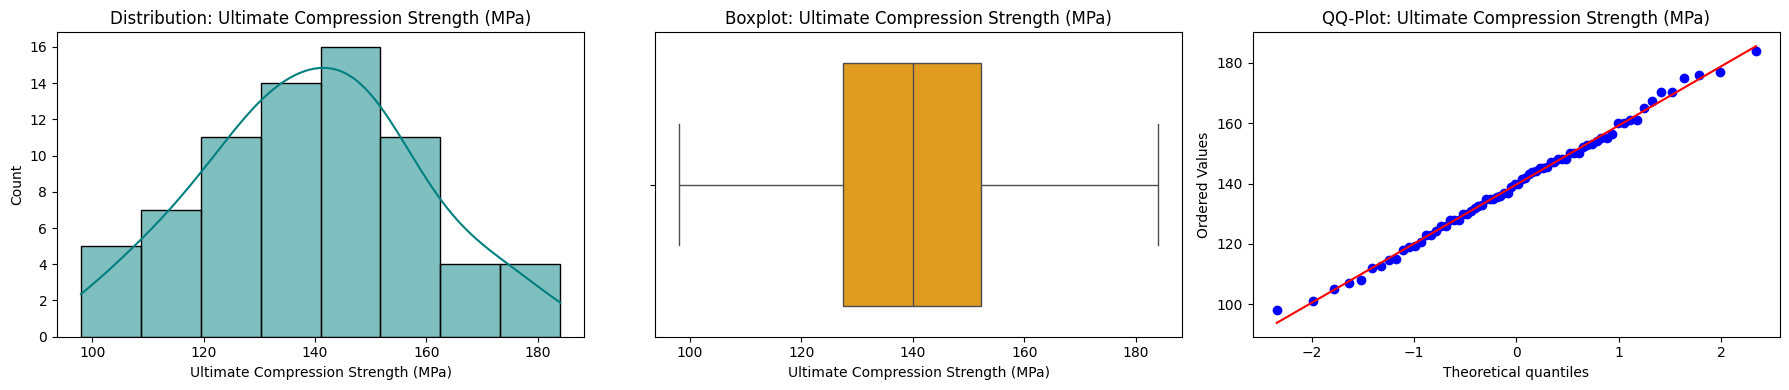

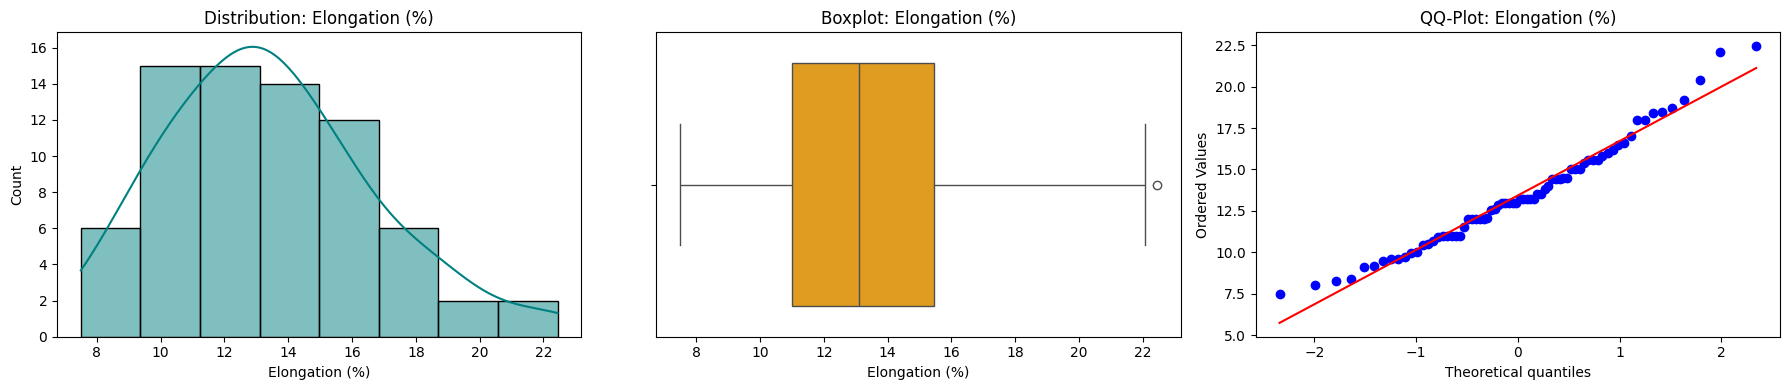

In [19]:
#  رسم ماتریس‌های همبستگی
correlation_methods = ['pearson', 'spearman', 'kendall']
for method in correlation_methods:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(method=method), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f"{method.upper()} Correlation Matrix")
    plt.show()

# رسم انواع مختلف توزیع ها برای فیچرها
for col in numeric_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    # Histogram & KDE
    sns.histplot(numeric_df[col], kde=True, ax=axes[0], color='teal')
    axes[0].set_title(f'Distribution: {col}')
    
    # Boxplot
    sns.boxplot(x=numeric_df[col], ax=axes[1], color='orange')
    axes[1].set_title(f'Boxplot: {col}')
    
    # QQ-Plot
    stats.probplot(numeric_df[col], dist="norm", plot=axes[2])
    axes[2].set_title(f'QQ-Plot: {col}')
    
    plt.tight_layout()
    plt.show()

# پیش‌ پردازش داده‌ها

In [20]:
# شناسایی داده‌های پرت (بدون حذف)
iso = IsolationForest(contamination=0.05, random_state=42)
lof = LocalOutlierFactor(n_neighbors=20)

df['Outlier_IsoForest'] = iso.fit_predict(numeric_df)
df['Outlier_LOF'] = lof.fit_predict(numeric_df)

# تبدیل به فرمت خواناتر (1: نرمال، -1: پرت)
df['Outlier_IsoForest'] = df['Outlier_IsoForest'].map({1: 'No', -1: 'Yes'})
df['Outlier_LOF'] = df['Outlier_LOF'].map({1: 'No', -1: 'Yes'})
 
 
input_cols = [
    "Tool Shape",
    "Rotational Speed",
    "Plunging Speed",
    "Composite Volume Fraction (%)"
]

target_cols = [
    "Si Particle Size (um)",
    "Hardness (HV)",
    "wear rate",
    "Ultimate Compression Strength (MPa)",
    "Elongation (%)",
]

# ساخت بخش ورودی ها و بخش ویژگی های هدف
X = df[input_cols].copy()
y = df[target_cols].copy()

# یافتن ستون ثابت
constant_cols = [col for col in X.columns if X[col].nunique(dropna=False) <= 1]
print("Constant columns:", constant_cols)

# حذف ستون ثابت
X = X.drop(columns=constant_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
display(y.head())


Constant columns: []
X shape: (72, 4)
y shape: (72, 5)


,Tool Shape,Rotational Speed,Plunging Speed,Composite Volume Fraction (%)
0,1,315,25.0,0
1,1,315,31.5,0
2,1,315,40.0,0
3,1,500,25.0,0
4,1,500,31.5,0


,Si Particle Size (um),Hardness (HV),wear rate,Ultimate Compression Strength (MPa),Elongation (%)
0,2.9,75.0,8.62,118.0,13.5
1,3.4,72.0,9.31,135.0,13.0
2,4.1,69.0,10.42,119.0,7.5
3,2.2,81.0,8.15,115.0,12.0
4,2.7,75.0,8.54,136.0,13.0


In [21]:
for col in X.columns:
    print(col, "->", sorted(X[col].unique()))

Tool Shape -> [1, 2, 3]
Rotational Speed -> [315, 500, 630, 800]
Plunging Speed -> [25.0, 31.5, 40.0]
Composite Volume Fraction (%) -> [0, 1]


# MLOPS PREPARATION REPORT

In [22]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold
import numpy as np

# --- تعریف ستون‌ها ---
categorical_features = ["Tool Shape"]
numeric_features = [c for c in X.columns if c not in categorical_features]

assert set(categorical_features + numeric_features) == set(X.columns), \
    f"ستون‌های پوشش‌ نداده: {set(X.columns) - set(categorical_features + numeric_features)}"

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="drop"
)

skewed_targets = ["Si Particle Size (um)"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

    # --- IQR Capping + log1p (پارامترها فقط از train) ---
    for col in skewed_targets:
        Q1, Q3 = y_train[col].quantile(0.25), y_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

        y_train[col] = np.log1p(y_train[col].clip(lower, upper))
        y_val[col]   = np.log1p(y_val[col].clip(lower, upper))  


    X_train_t = preprocessor.fit_transform(X_train)
    X_val_t   = preprocessor.transform(X_val)

    
print("\n=== MLOps PREPARATION REPORT (Dataset 0172) ===")
print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"Categorical: {categorical_features}")
print(f"Numeric (incl. Rotational Speed): {numeric_features}")
print(f"Log-transformed targets: {skewed_targets}")




=== MLOps PREPARATION REPORT (Dataset 0172) ===
Features: 4  |  Samples: 72
Categorical: ['Tool Shape']
Numeric (incl. Rotational Speed): ['Rotational Speed', 'Plunging Speed', 'Composite Volume Fraction (%)']
Log-transformed targets: ['Si Particle Size (um)']


In [23]:
import warnings
warnings.filterwarnings("ignore")

import mlflow
import mlflow.sklearn

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# تنظیمات اولیه برای آموزش مدل‌ها 

In [24]:
SEEDS = [42, 100, 2023, 7, 888]
EXPERIMENT_NAME = "Dataset_0172_SingleOutput_AllModels"
EARLY_STOP_MODELS = {"XGBoost", "LightGBM"}

In [25]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    y_range = np.max(y_true) - np.min(y_true)
    nrmse = rmse / y_range if y_range != 0 else 0.0

    return {
        "R2": r2,
        "RMSE": rmse,
        "NRMSE": nrmse,
        "MAE": mae
    }

# Cross Validation  تابع ساخت 

In [26]:
def make_cv(seed, n_splits=5):
    return KFold(n_splits=n_splits, shuffle=True, random_state=seed)

# ساخت پایپ‌لاین مدل‌سازی

In [27]:
from sklearn.base import clone
def build_pipeline(model, preprocessor):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", clone(model))
    ])

In [28]:
import inspect
print(inspect.getsource(build_pipeline))

def build_pipeline(model, preprocessor):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", clone(model))
    ])



# تعریف مدل ها

In [29]:
def get_models(seed=42):
    return {
        "Linear Regression": LinearRegression(),

        "Ridge": Ridge(alpha=1.0),

        "ElasticNet": ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            max_iter=5000,
            random_state=seed
        ),

        "SVR (RBF)": SVR(
            kernel="rbf",
            C=10.0,
            epsilon=0.1,
            gamma="scale"
        ),

        "GPR (Kriging)": GaussianProcessRegressor(
            kernel=C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
                   + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1)),
            alpha=1e-8,
            normalize_y=True,
            n_restarts_optimizer=5,
            random_state=seed
        ),

        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            min_samples_split=4,
            max_features="sqrt",
            random_state=seed,
            n_jobs=-1
        ),

        "Extra Trees": ExtraTreesRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            min_samples_split=4,
            max_features="sqrt",
            random_state=seed,
            n_jobs=-1
        ),

        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=2,
            subsample=0.8,
            validation_fraction=0.15,
            n_iter_no_change=20,
            tol=1e-4,
            random_state=seed
        ),

        "XGBoost": XGBRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            max_depth=3,
            min_child_weight=2,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=seed,
            n_jobs=-1
        ),

        "LightGBM": LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=5,
            subsample=0.8,
            subsample_freq=1,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=seed,
            n_jobs=-1,
            verbose=-1
        ),

        "ANN (MLP)": MLPRegressor(
            hidden_layer_sizes=(16,),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=5000,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=seed
        )
    }


# اجرای کامل فرآیند یادگیری مدل و پیش‌بینی خروجی‌ها

In [30]:
def fit_predict_standard_model(model, preprocessor, X_train, y_train, X_val, skewed_targets=None):
    """
    y_train, y_val: single-column Series or 1-D array for one target at a time.
    skewed_targets: list of target names that have log1p applied; pass [target_name]
                    if current target is skewed, else None or [].
    Returns (y_pred_original_scale, pipeline)
    """
    pipeline = build_pipeline(model, preprocessor)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    if skewed_targets:
        y_pred = np.expm1(y_pred)

    return y_pred, pipeline

# LightGBM و XGBoost آموزش اختصاصی مدل‌های 

In [31]:
def fit_predict_boosting_with_evalset(model_name, model, preprocessor, X_train, y_train, X_test, seed, is_skewed=False):
    # split داخلی train -> train/val برای early stopping
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=seed
    )

    pre = clone(preprocessor)
    X_tr_t = pre.fit_transform(X_tr)
    X_val_t = pre.transform(X_val)
    X_test_t = pre.transform(X_test)

    fitted_model = clone(model)

    if model_name == "XGBoost":
        fitted_model.fit(
            X_tr_t, y_tr,
            eval_set=[(X_val_t, y_val)],
            verbose=False
        )
    elif model_name == "LightGBM":
        fitted_model.fit(
            X_tr_t, y_tr,
            eval_set=[(X_val_t, y_val)],
            callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)]
        )

    y_pred = fitted_model.predict(X_test_t)

    if is_skewed:
        y_pred = np.expm1(y_pred)

    return y_pred, (pre, fitted_model)

# Orchestrator Function

In [32]:
SKEWED_TARGETS = {"Si Particle Size (um)"}

def run_single_fold(model_name, model, preprocessor, X_train, y_train, X_test, y_test, seed, target_name):
    is_skewed = target_name in SKEWED_TARGETS

    if model_name in EARLY_STOP_MODELS:
        y_pred, fitted_obj = fit_predict_boosting_with_evalset(
            model_name, model, preprocessor, X_train, y_train, X_test, seed, is_skewed=is_skewed
        )
    else:
        y_pred, fitted_obj = fit_predict_standard_model(
            model, preprocessor, X_train, y_train, X_test,
            skewed_targets=[target_name] if is_skewed else None
        )

    y_true = np.expm1(y_test) if is_skewed else y_test
    metrics = compute_metrics(y_true, y_pred)
    return metrics, fitted_obj

# MLflow ثبت شاخص‌های ارزیابی در 

In [33]:
def log_fold_metrics_to_mlflow(fold_idx, metrics):
    mlflow.log_metric(f"fold_{fold_idx}_R2", metrics["R2"])
    mlflow.log_metric(f"fold_{fold_idx}_RMSE", metrics["RMSE"])
    mlflow.log_metric(f"fold_{fold_idx}_NRMSE", metrics["NRMSE"])
    mlflow.log_metric(f"fold_{fold_idx}_MAE", metrics["MAE"])

## ثبت آمار کلی

In [34]:
def log_summary_to_mlflow(summary):
    for key, value in summary.items():
        mlflow.log_metric(key, value)

# Cross Validation اجرای کامل فرآیند

In [35]:
def evaluate_model_cv(model_name, model, X, y_target, preprocessor, seed, n_splits=5, verbose=True):
    cv = make_cv(seed, n_splits=n_splits)
    fold_metrics = []
    target_name = y_target.name

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y_target), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test  = X.iloc[test_idx].copy()
        y_train = y_target.iloc[train_idx].copy()
        y_test  = y_target.iloc[test_idx].copy()

        # IQR capping + log1p فقط روی target های skewed، با آمار محاسبه‌شده از train
        if target_name in SKEWED_TARGETS:
            Q1, Q3 = y_train.quantile(0.25), y_train.quantile(0.75)
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

            y_train = np.log1p(y_train.clip(lower, upper))
            y_test  = np.log1p(y_test.clip(lower, upper))

        metrics, _ = run_single_fold(
            model_name=model_name,
            model=model,
            preprocessor=preprocessor,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            seed=seed,
            target_name=target_name
        )

        fold_metrics.append(metrics)

        if verbose:
            print(
                f"{model_name} | seed={seed} | fold={fold_idx} | "
                f"R2={metrics['R2']:.4f} | RMSE={metrics['RMSE']:.4f} | "
                f"NRMSE={metrics['NRMSE']:.4f} | MAE={metrics['MAE']:.4f}"
            )

        log_fold_metrics_to_mlflow(fold_idx, metrics)

    summary = summarize_fold_metrics(fold_metrics)
    return summary

# اجرای کامل فرآیند یادگیری روی یک ستون هدف

In [36]:
def run_model_for_target(model_name, model, X, y_target, target_name, preprocessor, seed, n_splits=5):
    assert y_target.name == target_name, f"target_name mismatch: {y_target.name} vs {target_name}"

    with mlflow.start_run(run_name=f"{target_name}__{model_name}__seed{seed}"):
        mlflow.log_param("target", target_name)
        mlflow.log_param("model", model_name)
        mlflow.log_param("seed", seed)
        mlflow.log_param("cv_type", "KFold")
        mlflow.log_param("n_splits", n_splits)

        summary = evaluate_model_cv(
            model_name=model_name,
            model=model,
            X=X,
            y_target=y_target,
            preprocessor=preprocessor,
            seed=seed,
            n_splits=n_splits
        )

        log_summary_to_mlflow(summary)

        result = {
            "target": target_name,
            "model": model_name,
            "seed": seed,
            **summary
        }

    return result

# محاسبه میانگین هر شاخص ارزیابی برای مدل ها

In [37]:
def summarize_fold_metrics(fold_metrics):
    summary = {
        "mean_R2": np.mean([m["R2"] for m in fold_metrics]),
        "std_R2": np.std([m["R2"] for m in fold_metrics]),
        "mean_RMSE": np.mean([m["RMSE"] for m in fold_metrics]),
        "mean_NRMSE": np.mean([m["NRMSE"] for m in fold_metrics]),
        "mean_MAE": np.mean([m["MAE"] for m in fold_metrics]),
    }
    return summary

# اجرای کامل فرآیند ارزیابی یک مدل روی یک ستون هدف

In [38]:
def run_all_models_for_target(X, y, target_name, preprocessor, seeds, n_splits=5):
    y_target = y[target_name]
    results = []

    print("\n" + "=" * 90)
    print(f"Target: {target_name}")
    print("=" * 90)

    for seed in seeds:
        models = get_models(seed)

        for model_name, model in models.items():
            result = run_model_for_target(
                model_name=model_name,
                model=model,
                X=X,
                y_target=y_target,
                target_name=target_name,
                preprocessor=preprocessor,
                seed=seed,
                n_splits=n_splits
            )
            results.append(result)

    return results


# اجرای کامل آزمایش برای متغیر هدف و ثبت نتایج

In [39]:
def run_full_experiment(X, y, target_cols, preprocessor, seeds, experiment_name, n_splits=5):
    mlflow.set_experiment(experiment_name)

    all_results = []

    for target_name in target_cols:
        target_results = run_all_models_for_target(
            X=X,
            y=y,
            target_name=target_name,
            preprocessor=preprocessor,
            seeds=seeds,
            n_splits=n_splits
        )
        all_results.extend(target_results)

    results_df = pd.DataFrame(all_results)
    return results_df


In [40]:
import os
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

In [41]:
import lightgbm as lgb

results_df = run_full_experiment(
    X=X,
    y=y,
    target_cols=target_cols,
    preprocessor=preprocessor,
    seeds=SEEDS,
    experiment_name=EXPERIMENT_NAME,
    n_splits=5
)

print("\n✅ All experiments completed.")
display(results_df.head())


Target: Si Particle Size (um)
Linear Regression | seed=42 | fold=1 | R2=0.8837 | RMSE=0.3202 | NRMSE=0.1097 | MAE=0.2307
Linear Regression | seed=42 | fold=2 | R2=0.8763 | RMSE=0.1887 | NRMSE=0.0943 | MAE=0.1591
Linear Regression | seed=42 | fold=3 | R2=0.9429 | RMSE=0.2123 | NRMSE=0.0856 | MAE=0.1676
Linear Regression | seed=42 | fold=4 | R2=0.9692 | RMSE=0.1408 | NRMSE=0.0504 | MAE=0.1058
Linear Regression | seed=42 | fold=5 | R2=0.9596 | RMSE=0.2217 | NRMSE=0.0710 | MAE=0.1543
Ridge | seed=42 | fold=1 | R2=0.8673 | RMSE=0.3420 | NRMSE=0.1171 | MAE=0.2433
Ridge | seed=42 | fold=2 | R2=0.8783 | RMSE=0.1871 | NRMSE=0.0936 | MAE=0.1576
Ridge | seed=42 | fold=3 | R2=0.9463 | RMSE=0.2060 | NRMSE=0.0831 | MAE=0.1563
Ridge | seed=42 | fold=4 | R2=0.9687 | RMSE=0.1418 | NRMSE=0.0508 | MAE=0.1056
Ridge | seed=42 | fold=5 | R2=0.9490 | RMSE=0.2490 | NRMSE=0.0797 | MAE=0.1657
ElasticNet | seed=42 | fold=1 | R2=0.8330 | RMSE=0.3837 | NRMSE=0.1314 | MAE=0.2708
ElasticNet | seed=42 | fold=2 | R2=

,target,model,seed,mean_R2,std_R2,mean_RMSE,mean_NRMSE,mean_MAE
0,Si Particle Size (um),Linear Regression,42,0.926328,0.038828,0.216730,0.082212,0.163495
1,Si Particle Size (um),Ridge,42,0.921917,0.040987,0.225193,0.084867,0.165688
2,Si Particle Size (um),ElasticNet,42,0.911901,0.050391,0.240128,0.089744,0.172500
3,Si Particle Size (um),SVR (RBF),42,0.927265,0.035642,0.218523,0.081903,0.169431
4,Si Particle Size (um),GPR (Kriging),42,0.977960,0.007802,0.127323,0.046976,0.084117


 # Initial Hyperparameter Optimization

In [ ]:

RANKING_WEIGHTS = {
    "performance_r2": 0.40,
    "performance_rmse": 0.20,
    "performance_mae": 0.10,
    "stability": 0.20,
    "interpretability": 0.10
}

INTERPRETABILITY_MAP = {
    "Linear Regression": 1.0,
    "Ridge": 0.95,
    "ElasticNet": 0.95,
    "SVR (RBF)": 0.6,
    "GPR (Kriging)": 0.5,
    "Random Forest": 0.75,
    "Extra Trees": 0.75,
    "Gradient Boosting": 0.7,
    "XGBoost": 0.65,
    "LightGBM": 0.65,
    "ANN": 0.3
}

def calculate_final_rankings(df):
    def norm(s, higher_better=True):
        rng = s.max() - s.min()
        if rng == 0:
            return pd.Series(1.0, index=s.index)
        n = (s - s.min()) / rng
        return n if higher_better else 1 - n

    results = []
    for _, group in df.groupby("target"):
        g = group.copy()
        g['norm_R2']        = norm(g['mean_R2'])
        g['norm_RMSE']      = norm(g['mean_RMSE'], higher_better=False)
        g['norm_MAE']       = norm(g['mean_MAE'],  higher_better=False)
        g['norm_Stability'] = norm(g['std_R2'],    higher_better=False)
        g['score_interp']   = g['model'].map(INTERPRETABILITY_MAP).fillna(0.5)
        g['Overall_Score']  = (
            g['norm_R2']        * RANKING_WEIGHTS["performance_r2"]  +
            g['norm_RMSE']      * RANKING_WEIGHTS["performance_rmse"] +
            g['norm_MAE']       * RANKING_WEIGHTS["performance_mae"]  +
            g['norm_Stability'] * RANKING_WEIGHTS["stability"]        +
            g['score_interp']   * RANKING_WEIGHTS["interpretability"]
        )
        results.append(g)

    return pd.concat(results).sort_values(["target", "Overall_Score"], ascending=[True, False])

agg_df = results_df.groupby(["target", "model"], as_index=False).agg(
    mean_R2=("mean_R2", "mean"),
    std_R2=("std_R2", "mean"),
    mean_RMSE=("mean_RMSE", "mean"),
    mean_MAE=("mean_MAE", "mean")
)

ranked_df = calculate_final_rankings(agg_df)

top3_models = ranked_df.groupby("target").head(3)

print("--- Top 3 Models Selected for Next Phases (Aggregated) ---")
display(top3_models[['target', 'model', 'mean_R2', 'std_R2', 'Overall_Score']])

--- Top 3 Models Selected for Next Phases (Aggregated) ---


,target,model,mean_R2,std_R2,Overall_Score
10,Elongation (%),XGBoost,0.725800,0.155072,0.949659
4,Elongation (%),Gradient Boosting,0.684587,0.111820,0.927459
9,Elongation (%),SVR (RBF),0.561879,0.153121,0.807252
17,Hardness (HV),Linear Regression,0.902769,0.053499,0.982098
12,Hardness (HV),ElasticNet,0.902552,0.053219,0.977076
19,Hardness (HV),Ridge,0.899700,0.053445,0.975692
26,Si Particle Size (um),Gradient Boosting,0.978660,0.011243,0.970000
27,Si Particle Size (um),LightGBM,0.973446,0.013780,0.932287
32,Si Particle Size (um),XGBoost,0.972462,0.015598,0.923996
43,Ultimate Compression Strength (MPa),XGBoost,0.870211,0.065827,0.963338


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic

PARAM_DISTRIBUTIONS = {
    "Linear Regression": {},
    "Ridge": {"regressor__alpha": np.logspace(-4, 3, 50)},
    "ElasticNet": {
        "regressor__alpha": np.logspace(-4, 3, 50),
        "regressor__l1_ratio": np.linspace(0.1, 0.9, 10)
    },
    "Gradient Boosting": {
        "regressor__n_estimators": [50, 100, 150, 200],
        "regressor__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "regressor__max_depth": [3, 4, 5, 6],
        "regressor__min_samples_split": [2, 5, 10],
        "regressor__subsample": [0.7, 0.8, 0.9, 1.0]
    },
    "GPR (Kriging)": {
        "regressor__alpha": np.logspace(-10, -1, 10),
        "regressor__kernel": [
            1.0 * RBF(length_scale=1.0),
            1.0 * Matern(length_scale=1.0, nu=1.5),
            1.0 * RationalQuadratic(length_scale=1.0, alpha=0.1)
        ]
    }
}

try:
    import xgboost as xgb
    PARAM_DISTRIBUTIONS["XGBoost"] = {
        "regressor__n_estimators": [50, 100, 150, 200],
        "regressor__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "regressor__max_depth": [3, 4, 5, 6],
        "regressor__subsample": [0.7, 0.8, 0.9, 1.0],
        "regressor__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
    }
except ImportError:
    pass


def run_random_search_on_top_models(top3_df, X_df, Y_df, cv_splitter, preprocessor,
                                     n_iter=10, random_state=42):
    opt_results = []
    top_jobs = top3_df[["target", "model"]].to_dict(orient="records")
    print(f"Starting Random Search for {len(top_jobs)} target-model combinations...")

    for job in top_jobs:
        target = job["target"]
        model_name = job["model"]
        print(f"\n>>> Optimizing '{model_name}' for target '{target}'...")

        y = Y_df[target].dropna()
        X = X_df.loc[y.index]

        is_skewed = target in SKEWED_TARGETS
        if is_skewed:
            cv = make_cv(random_state)
            y_transformed = y.copy()
            # IQR capping + log1p روی کل y برای random search (تقریبی)
            Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
            IQR = Q3 - Q1
            y_transformed = y_transformed.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
            y_transformed = np.log1p(y_transformed)
            y_fit = y_transformed
        else:
            y_fit = y

        models_dict = get_models(random_state)
        if model_name not in models_dict:
            print(f"Model {model_name} not found. Skipping.")
            continue

        base_model = models_dict[model_name]
        pipeline = build_pipeline(base_model, preprocessor)
        param_dist = PARAM_DISTRIBUTIONS.get(model_name, {})

        if not param_dist:
            print(f"No hyperparameters to tune for {model_name}.")
            opt_results.append({
                "target": target,
                "model": model_name,
                "best_params": {},
                "best_r2_score": "N/A"
            })
            continue

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_dist,
            n_iter=n_iter,
            scoring="r2",
            cv=cv_splitter,
            n_jobs=-1,
            random_state=random_state,
            error_score="raise"
        )

        try:
            search.fit(X, y_fit)
            print(f"Best Params: {search.best_params_}")
            print(f"Best CV R2: {search.best_score_:.4f}")
            opt_results.append({
                "target": target,
                "model": model_name,
                "best_params": search.best_params_,
                "best_r2_score": search.best_score_
            })
        except Exception as e:
            print(f"Failed for {model_name}: {e}")

    return pd.DataFrame(opt_results)


In [ ]:
from sklearn.model_selection import KFold

cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

optimization_results = run_random_search_on_top_models(
    top3_df=top3_models,
    X_df=X,
    Y_df=y,
    cv_splitter=cv_splitter,
    preprocessor=preprocessor,
    n_iter=10,
    random_state=42
)

display(optimization_results)

Starting Random Search for 15 target-model combinations...

>>> Optimizing 'XGBoost' for target 'Elongation (%)'...
Best Params: {'regressor__subsample': 0.7, 'regressor__n_estimators': 200, 'regressor__max_depth': 4, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 1.0}
Best CV R2: 0.7180

>>> Optimizing 'Gradient Boosting' for target 'Elongation (%)'...
Best Params: {'regressor__subsample': 0.7, 'regressor__n_estimators': 50, 'regressor__min_samples_split': 2, 'regressor__max_depth': 4, 'regressor__learning_rate': 0.2}
Best CV R2: 0.6785

>>> Optimizing 'SVR (RBF)' for target 'Elongation (%)'...
No hyperparameters to tune for SVR (RBF).

>>> Optimizing 'Linear Regression' for target 'Hardness (HV)'...
No hyperparameters to tune for Linear Regression.

>>> Optimizing 'ElasticNet' for target 'Hardness (HV)'...
Best Params: {'regressor__l1_ratio': 0.4555555555555556, 'regressor__alpha': 0.005179474679231213}
Best CV R2: 0.8777

>>> Optimizing 'Ridge' for target 'Hardness

,target,model,best_params,best_r2_score
0,Elongation (%),XGBoost,"{'regressor__subsample': 0.7, 'regressor__n_es...",0.718047
1,Elongation (%),Gradient Boosting,"{'regressor__subsample': 0.7, 'regressor__n_es...",0.678499
2,Elongation (%),SVR (RBF),{},N/A
3,Hardness (HV),Linear Regression,{},N/A
4,Hardness (HV),ElasticNet,"{'regressor__l1_ratio': 0.4555555555555556, 'r...",0.877725
5,Hardness (HV),Ridge,{'regressor__alpha': 0.3727593720314938},0.87789
6,Si Particle Size (um),Gradient Boosting,"{'regressor__subsample': 0.7, 'regressor__n_es...",0.990774
7,Si Particle Size (um),LightGBM,{},N/A
8,Si Particle Size (um),XGBoost,"{'regressor__subsample': 0.7, 'regressor__n_es...",0.982976
9,Ultimate Compression Strength (MPa),XGBoost,"{'regressor__subsample': 0.7, 'regressor__n_es...",0.88606


In [ ]:
from sklearn.model_selection import cross_val_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, model_name, pipeline, X, y, cv):
    if model_name == "Gradient Boosting":
        params = {
            "regressor__n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "regressor__learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            "regressor__max_depth": trial.suggest_int("max_depth", 3, 8),
            "regressor__subsample": trial.suggest_float("subsample", 0.6, 1.0),
        }
    elif model_name == "XGBoost":
        params = {
            "regressor__n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "regressor__learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            "regressor__max_depth": trial.suggest_int("max_depth", 3, 8),
            "regressor__subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "regressor__colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        }
    elif model_name == "Ridge":
        params = {"regressor__alpha": trial.suggest_float("alpha", 1e-5, 100, log=True)}
    elif model_name == "ElasticNet":
        params = {
            "regressor__alpha": trial.suggest_float("alpha", 1e-5, 100, log=True),
            "regressor__l1_ratio": trial.suggest_float("l1_ratio", 0.1, 0.9),
        }
    else:
        params = {}

    pipeline.set_params(**params)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="r2")
    return scores.mean()


def run_bayesian_optimization(top3_df, X_df, Y_df, preprocessor, n_trials=20, random_state=42):
    results_optuna = []
    mlflow.set_experiment("MLOps_Bayesian_Optimization")

    for _, row in top3_df.iterrows():
        target = row["target"]
        model_name = row["model"]
        print(f"\n[Optuna] Optimizing {model_name} for {target}...")

        y_target = Y_df[target].dropna()
        X_target = X_df.loc[y_target.index]

        is_skewed = target in SKEWED_TARGETS
        if is_skewed:
            # تقریبی — leakage کامل حذف نمی‌شود اما بهتر از نسخه قبل است
            Q1, Q3 = y_target.quantile(0.25), y_target.quantile(0.75)
            IQR = Q3 - Q1
            y_fit = np.log1p(y_target.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR))
        else:
            y_fit = y_target

        models_dict = get_models(random_state)
        if model_name not in models_dict:
            print(f"  Model {model_name} not found. Skipping.")
            continue

        pipeline = build_pipeline(models_dict[model_name], preprocessor)
        cv = make_cv(random_state)

        with mlflow.start_run(run_name=f"Optuna_{target}_{model_name}"):
            study = optuna.create_study(direction="maximize",
                                        sampler=optuna.samplers.TPESampler(seed=random_state))
            study.optimize(
                lambda trial: objective(trial, model_name, clone(pipeline), X_target, y_fit, cv),
                n_trials=n_trials,
                show_progress_bar=False
            )

            mlflow.log_param("target", target)
            mlflow.log_param("model_type", model_name)
            mlflow.log_params(study.best_params)
            mlflow.log_metric("best_r2", study.best_value)

            results_optuna.append({
                "target": target,
                "model": model_name,
                "best_r2_optuna": round(study.best_value, 4),
                "best_params": study.best_params,
            })
            print(f"  -> Best R2: {study.best_value:.4f}")

    return pd.DataFrame(results_optuna)


# اجرا
optuna_results_df = run_bayesian_optimization(top3_models, X, y, preprocessor=preprocessor)
display(optuna_results_df)



[Optuna] Optimizing XGBoost for Elongation (%)...
  -> Best R2: 0.7373

[Optuna] Optimizing Gradient Boosting for Elongation (%)...
  -> Best R2: 0.6663

[Optuna] Optimizing SVR (RBF) for Elongation (%)...
  -> Best R2: 0.4866

[Optuna] Optimizing Linear Regression for Hardness (HV)...
  -> Best R2: 0.8773

[Optuna] Optimizing ElasticNet for Hardness (HV)...
  -> Best R2: 0.8778

[Optuna] Optimizing Ridge for Hardness (HV)...
  -> Best R2: 0.8778

[Optuna] Optimizing Gradient Boosting for Si Particle Size (um)...
  -> Best R2: 0.9891

[Optuna] Optimizing LightGBM for Si Particle Size (um)...
  -> Best R2: 0.9847

[Optuna] Optimizing XGBoost for Si Particle Size (um)...
  -> Best R2: 0.9838

[Optuna] Optimizing XGBoost for Ultimate Compression Strength (MPa)...
  -> Best R2: 0.8939

[Optuna] Optimizing Gradient Boosting for Ultimate Compression Strength (MPa)...
  -> Best R2: 0.8550

[Optuna] Optimizing LightGBM for Ultimate Compression Strength (MPa)...
  -> Best R2: 0.8881

[Optuna] 

,target,model,best_r2_optuna,best_params
0,Elongation (%),XGBoost,0.7373,"{'n_estimators': 55, 'learning_rate': 0.170526..."
1,Elongation (%),Gradient Boosting,0.6663,"{'n_estimators': 165, 'learning_rate': 0.09681..."
2,Elongation (%),SVR (RBF),0.4866,{}
3,Hardness (HV),Linear Regression,0.8773,{}
4,Hardness (HV),ElasticNet,0.8778,"{'alpha': 0.006299109534128049, 'l1_ratio': 0...."
5,Hardness (HV),Ridge,0.8778,{'alpha': 0.5327870491669573}
6,Si Particle Size (um),Gradient Boosting,0.9891,"{'n_estimators': 233, 'learning_rate': 0.04560..."
7,Si Particle Size (um),LightGBM,0.9847,{}
8,Si Particle Size (um),XGBoost,0.9838,"{'n_estimators': 153, 'learning_rate': 0.11940..."
9,Ultimate Compression Strength (MPa),XGBoost,0.8939,"{'n_estimators': 153, 'learning_rate': 0.11940..."


# بررسی میزان تاثیرگذاری ورودی های مختلف بر هر تارگت

                                target              model  best_r2_optuna
0                Si Particle Size (um)  Gradient Boosting          0.9891
1                            wear rate           LightGBM          0.9824
2  Ultimate Compression Strength (MPa)            XGBoost          0.8939
3                        Hardness (HV)         ElasticNet          0.8778
4                       Elongation (%)            XGBoost          0.7373

[Si Particle Size (um)] model=Gradient Boosting, params={'n_estimators': 233, 'learning_rate': 0.04560326152619243, 'max_depth': 3, 'subsample': 0.8478135772534396}
  fit OK


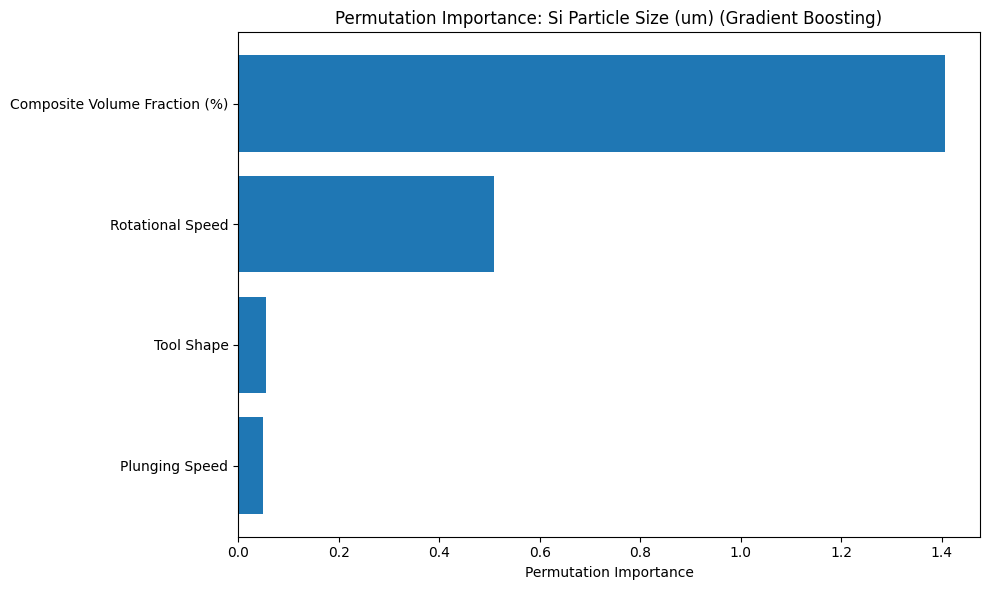

  permutation importance plot shown


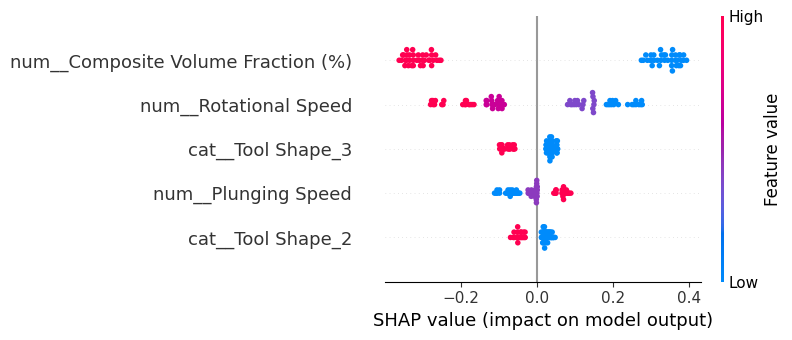

  SHAP summary plot shown


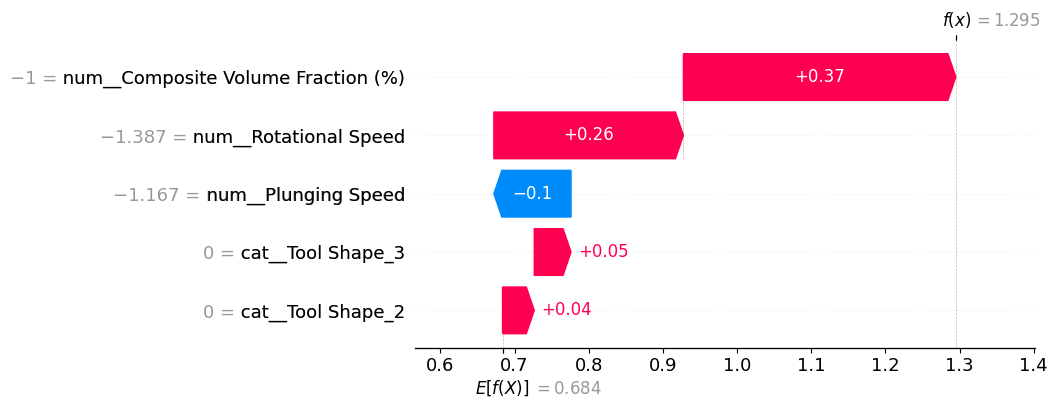

  SHAP waterfall (sample 0) shown

[wear rate] model=LightGBM, params={}
  fit OK


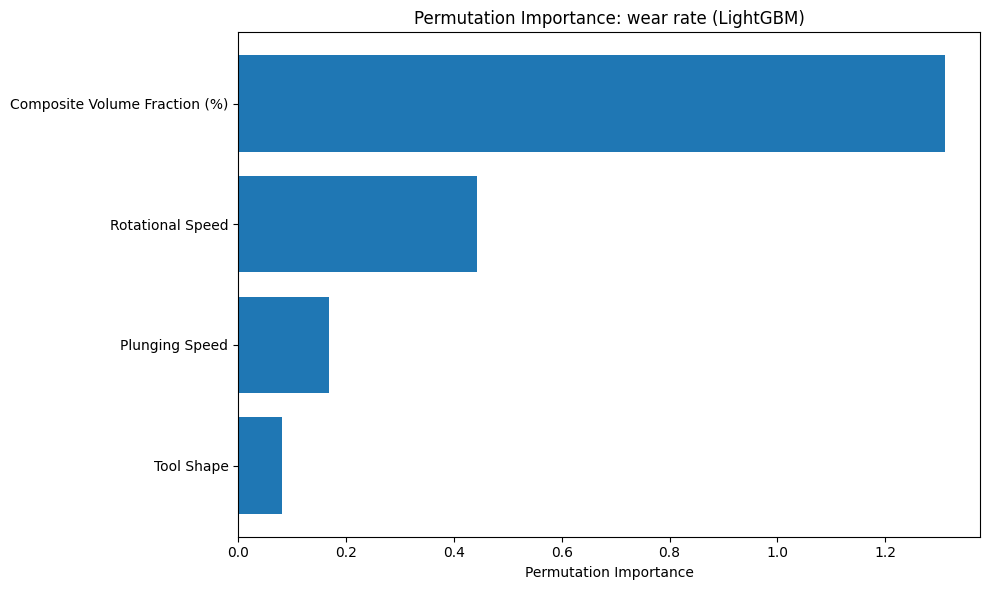

  permutation importance plot shown


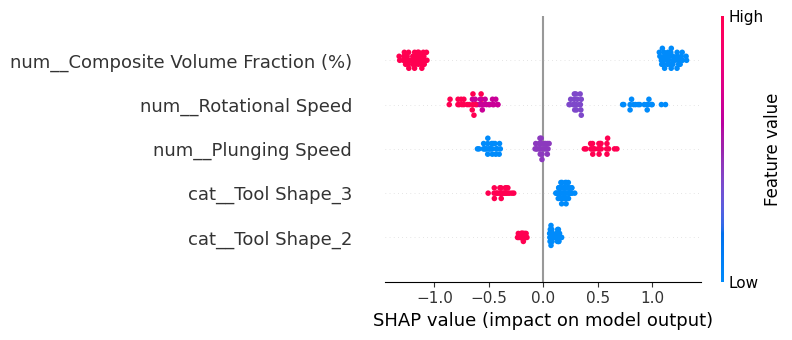

  SHAP summary plot shown


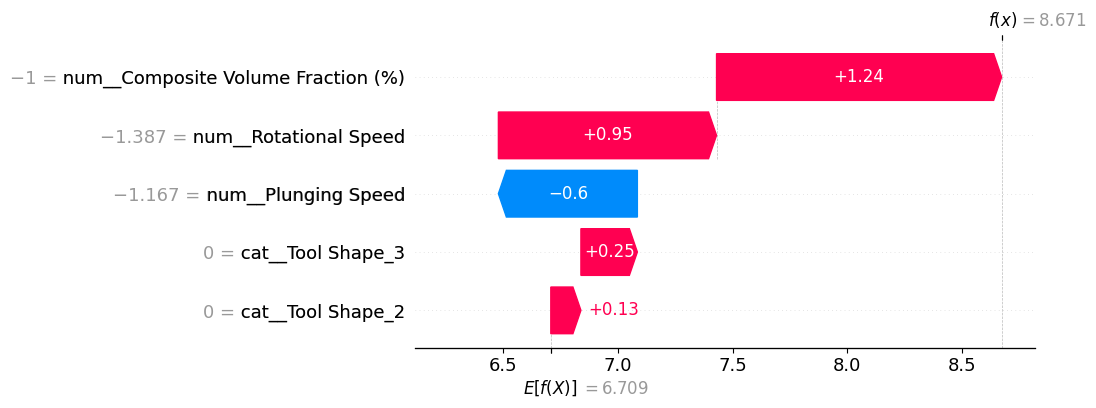

  SHAP waterfall (sample 0) shown

[Ultimate Compression Strength (MPa)] model=XGBoost, params={'n_estimators': 153, 'learning_rate': 0.11940806109352628, 'max_depth': 5, 'subsample': 0.6071847502459279, 'colsample_bytree': 0.984730551577528}
  fit OK


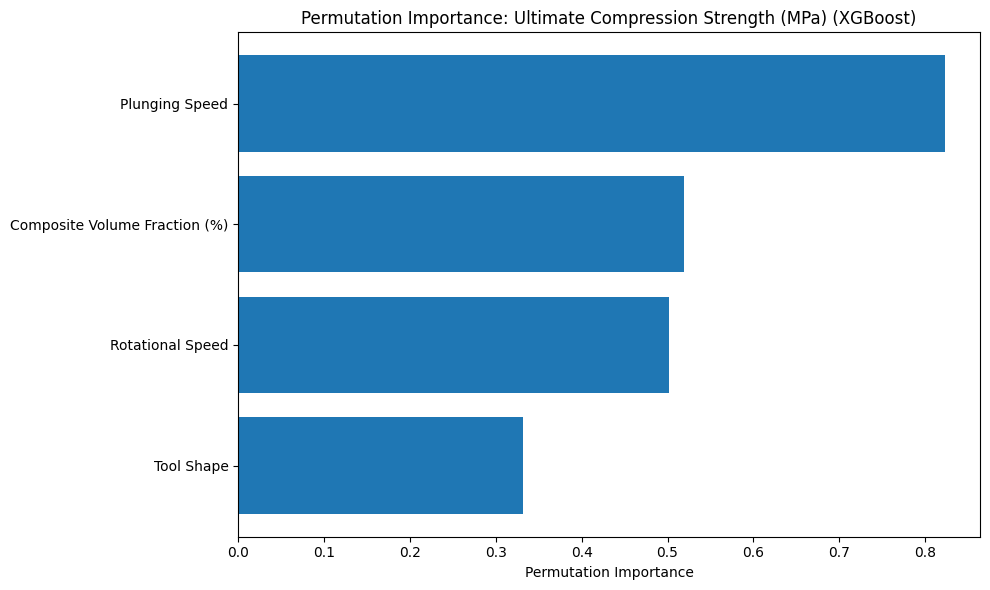

  permutation importance plot shown
  SHAP failed for XGBoost: could not convert string to float: '[1.3967819E2]'


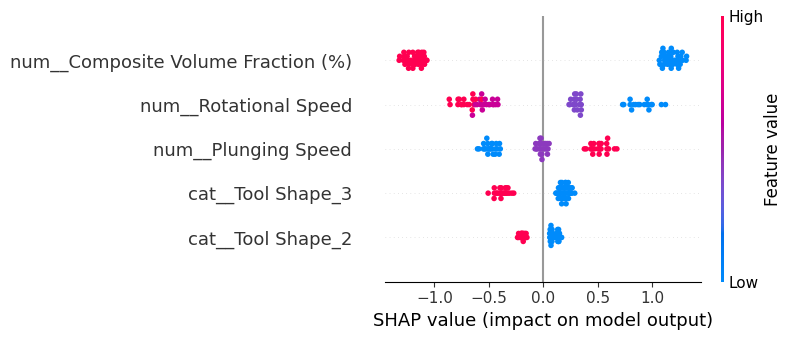

  SHAP summary plot shown


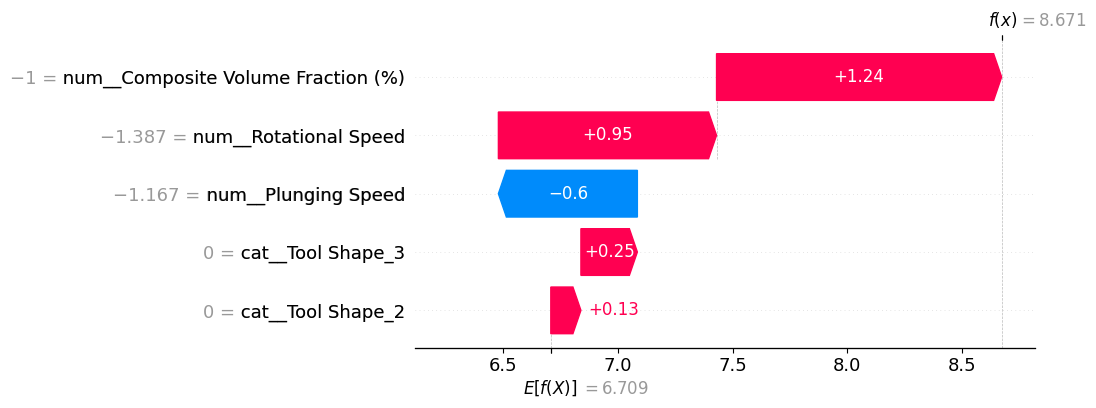

  SHAP waterfall (sample 0) shown

[Hardness (HV)] model=ElasticNet, params={'alpha': 0.006299109534128049, 'l1_ratio': 0.3781515057485808}
  fit OK


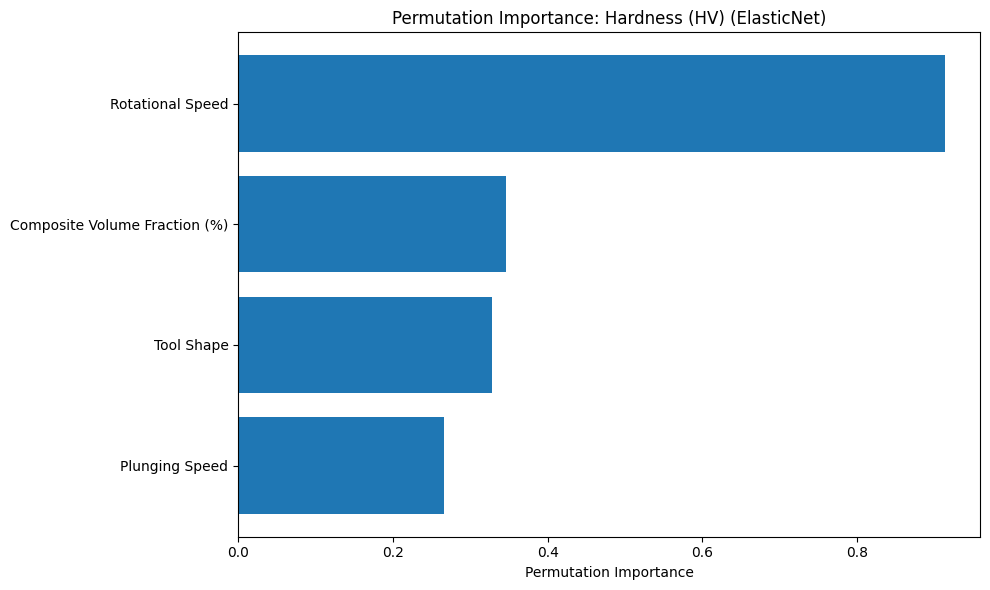

  permutation importance plot shown


100%|██████████| 72/72 [00:00<00:00, 545.96it/s]


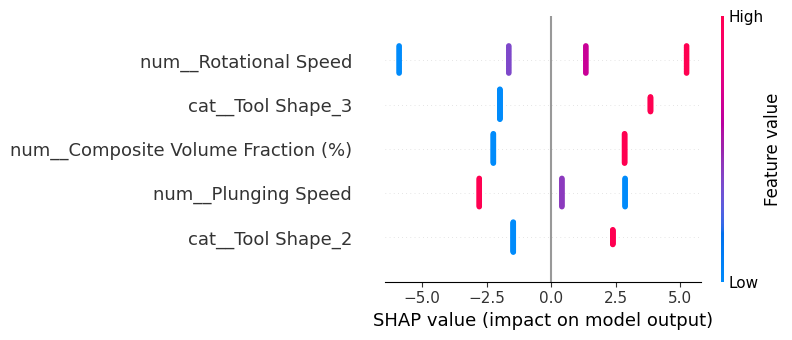

  SHAP summary plot shown


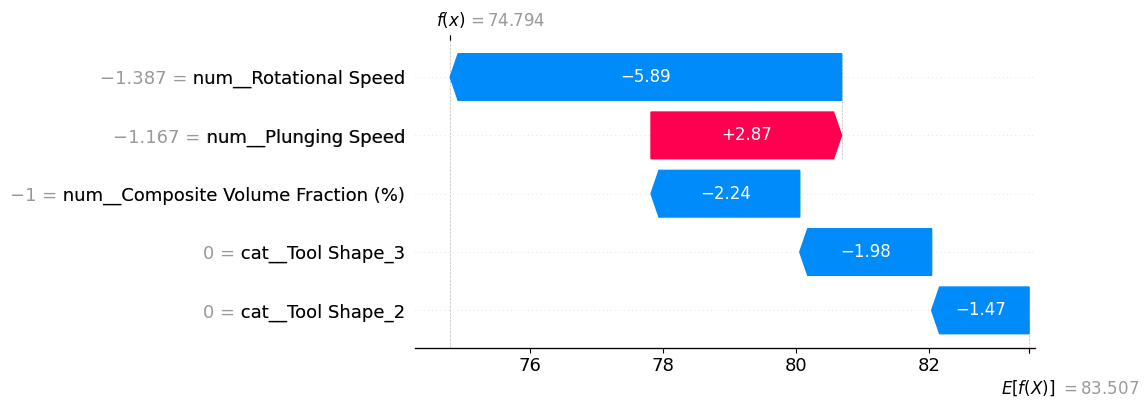

  SHAP waterfall (sample 0) shown

[Elongation (%)] model=XGBoost, params={'n_estimators': 55, 'learning_rate': 0.17052641538983093, 'max_depth': 7, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402}
  fit OK


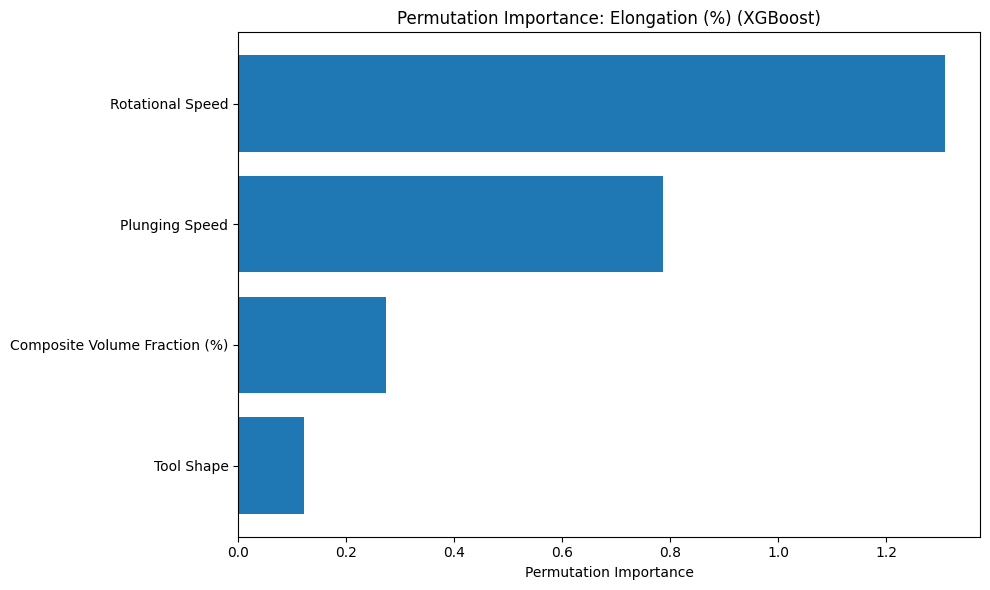

  permutation importance plot shown
  SHAP failed for XGBoost: could not convert string to float: '[1.3431528E1]'


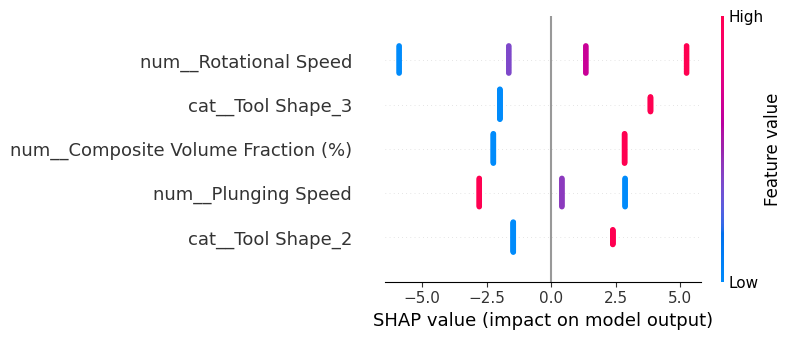

  SHAP summary plot shown


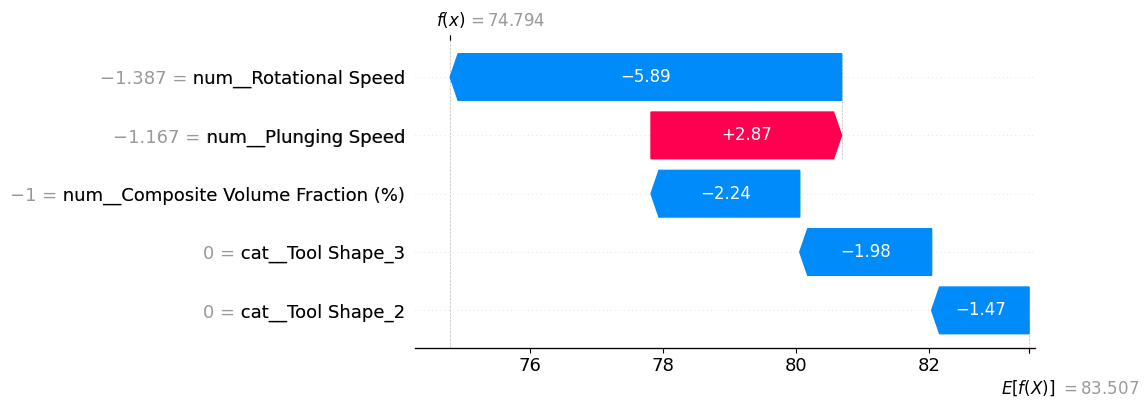

  SHAP waterfall (sample 0) shown


In [ ]:
import re
from sklearn.inspection import permutation_importance

def clean_bracket_string(val):
    if isinstance(val, str):
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", val)
        if m:
            return float(m.group())
    return val

def finalize_and_analyze(opt_df, X_df, y_df, preprocessor):
    best_overall = opt_df.sort_values("best_r2_optuna", ascending=False).groupby("target").head(1).reset_index(drop=True)
    print(best_overall[["target", "model", "best_r2_optuna"]].to_string())

    for _, row in best_overall.iterrows():
        target = row['target']
        model_name = row['model']
        raw_params = row['best_params'] if isinstance(row['best_params'], dict) else {}
        print(f"\n[{target}] model={model_name}, params={raw_params}")

        y_full = y_df[target].dropna()
        X_subset = X_df.loc[y_full.index]

        # ---------- Cleaning: handle stringified array values like "[13.431528]" ----------
        for col in X_subset.columns:
            if X_subset[col].dtype == object:
                X_subset[col] = X_subset[col].map(clean_bracket_string)
        X_subset = X_subset.apply(pd.to_numeric, errors="coerce")

        if X_subset.isnull().any().any():
            bad_cols = X_subset.columns[X_subset.isnull().any()].tolist()
            print(f"  Warning: NaNs after cleaning in columns: {bad_cols}")
            X_subset = X_subset.fillna(X_subset.median())

        is_skewed = target in SKEWED_TARGETS
        if is_skewed:
            q1, q3 = y_full.quantile(0.25), y_full.quantile(0.75)
            iqr = q3 - q1
            y_fit = np.log1p(y_full.clip(q1 - 1.5*iqr, q3 + 1.5*iqr))
        else:
            y_fit = y_full

        base_model = clone(get_models(seed=42)[model_name])
        if raw_params:
            base_model.set_params(**raw_params)

        pipeline = build_pipeline(base_model, preprocessor)
        pipeline.fit(X_subset, y_fit)
        print(f"  fit OK")

        # ---------- Permutation Importance ----------
        perm_imp = permutation_importance(pipeline, X_subset, y_fit, n_repeats=10, random_state=42)
        sorted_idx = perm_imp.importances_mean.argsort()[-10:]

        plt.figure(figsize=(10, 6))
        plt.barh(X_subset.columns[sorted_idx], perm_imp.importances_mean[sorted_idx])
        plt.title(f"Permutation Importance: {target} ({model_name})")
        plt.xlabel("Permutation Importance")
        plt.tight_layout()
        plt.show()
        print(f"  permutation importance plot shown")

        # ---------- SHAP ----------
        try:
            import shap

            model_step = pipeline[-1]
            X_transformed = pipeline[:-1].transform(X_subset)

            if hasattr(X_transformed, "toarray"):
                X_transformed = X_transformed.toarray()

            # پاک‌سازی هر مقدار رشته‌ای باقی‌مانده بعد از transform
            def _to_float(v):
                if isinstance(v, str):
                    m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", v)
                    return float(m.group()) if m else 0.0
                return v

            X_transformed = np.array(
                [[_to_float(v) for v in row] for row in X_transformed],
                dtype=float
            )

            try:
                feature_names = pipeline[:-1].get_feature_names_out().tolist()
            except Exception:
                feature_names = X_subset.columns.tolist()

            tree_keywords = ("XGB", "LGBM", "RandomForest", "GradientBoosting", "ExtraTrees", "DecisionTree")
            model_type_name = type(model_step).__name__

            if any(k in model_type_name for k in tree_keywords):
                explainer = shap.TreeExplainer(model_step)
                shap_values = explainer.shap_values(X_transformed)
                base_value = explainer.expected_value
                X_plot = X_transformed
            else:
                n_bg = min(50, X_transformed.shape[0])
                background = shap.sample(X_transformed, n_bg)
                explainer = shap.KernelExplainer(model_step.predict, background)
                n_show = min(100, X_transformed.shape[0])
                shap_values = explainer.shap_values(X_transformed[:n_show])
                base_value = explainer.expected_value
                X_plot = X_transformed[:n_show]

            if isinstance(base_value, (list, np.ndarray)):
                base_value = np.array(base_value).ravel()[0]

            shap.summary_plot(shap_values, X_plot, feature_names=feature_names, show=True)
            print(f"  SHAP summary plot shown")

            sample_explanation = shap.Explanation(
                values=shap_values[0],
                base_values=base_value,
                data=X_plot[0],
                feature_names=feature_names
            )
            shap.plots.waterfall(sample_explanation, show=True)
            print(f"  SHAP waterfall (sample 0) shown")

        except Exception as e:
            print(f"  SHAP failed for {model_name}: {e}", flush=True)


            # ---- SHAP Summary (global) ----
            shap.summary_plot(
                shap_values, X_plot,
                feature_names=feature_names, show=True
            )
            print(f"  SHAP summary plot shown")

            # ---- SHAP Waterfall - sample 0 (local) ----
            sample_explanation = shap.Explanation(
                values=shap_values[0],
                base_values=base_value,
                data=X_plot[0],
                feature_names=feature_names
            )
            shap.plots.waterfall(sample_explanation, show=True)
            print(f"  SHAP waterfall (sample 0) shown")

        except Exception as e:
            print(f"  SHAP failed for {model_name}: {e}", flush=True)

    return best_overall

best_overall = finalize_and_analyze(optuna_results_df, X, y, preprocessor)


In [ ]:
import os
import mlflow

# ساخت مسیر مطلق به صورت امن برای سیستم‌عامل
db_path = os.path.abspath(
    "C:/Users/ASUS/Desktop/miniproject-ds2/mini_project2/mlflow.db"
)
mlflow.set_tracking_uri(f"sqlite:///{db_path}")

mlflow.set_experiment("My_Experiment")

with mlflow.start_run():
    mlflow.log_param("model", "Ridge")
    
    mlflow.log_param("alpha", 1.0)
    mlflow.log_metric("r2_score", 0.91)

print("Run logged to:", mlflow.get_tracking_uri())



Run logged to: sqlite:///C:\Users\ASUS\Desktop\miniproject-ds2\mini_project2\mlflow.db


# آزمون آماری نهایی برای ارزیابی پروژه

In [ ]:

import scikit_posthocs as sp
from scipy.stats import friedmanchisquare

#  نتایج مدل‌ها 
results = {
    'XGBoost': [0.88, 0.85, 0.86, 0.87, 0.89],
    'RandomForest': [0.84, 0.82, 0.83, 0.85, 0.84],
    'SVR': [0.78, 0.75, 0.77, 0.76, 0.79]
}

# تبدیل به دیتافریم (هر ستون یک مدل)
df = pd.DataFrame(results)

#  Friedman Test 
stat, p_friedman = friedmanchisquare(*[df[col] for col in df.columns])
print(f"Friedman Test: Statistics={stat:.3f}, p-value={p_friedman:.4f}")

#  اجرای Nemenyi 
if p_friedman < 0.05:
    print("\nNemenyi Post-hoc Test (p-values):")
   
    nemenyi_results = sp.posthoc_nemenyi_friedman(df.values)
    nemenyi_results.columns = df.columns
    nemenyi_results.index = df.columns
    print(nemenyi_results)
else:
    print("\nNo significant difference found between models.")

Friedman Test: Statistics=10.000, p-value=0.0067

Nemenyi Post-hoc Test (p-values):
               XGBoost  RandomForest       SVR
XGBoost       1.000000      0.253784  0.004464
RandomForest  0.253784      1.000000  0.253784
SVR           0.004464      0.253784  1.000000
